## Session 26 - Q1-9

In [1]:
'''
Q1. Understanding & Dataset Creation
'''

from sklearn.datasets import make_blobs
import pandas as pd

# Create Synthetic Dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

# Convert into DataFrame
df = pd.DataFrame(
    X,
    columns=["Feature1", "Feature2"]
)

# Display First 10 Rows
print(df.head(10))

# Display Shape
print("\nDataset Shape:", df.shape)

   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

Dataset Shape: (500, 2)


In [3]:
'''
Q2. Data Scaling
'''

from sklearn.preprocessing import StandardScaler

# Standard Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# Display First 5 Rows
print(pd.DataFrame(X_scaled, columns=df.columns).head())

   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


In [4]:
'''
Q3. Basic K-Means Clustering
'''

from sklearn.cluster import KMeans

# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Fit the Model and Predict Clusters
clusters = kmeans.fit_predict(X_scaled)

# Add Cluster Labels to DataFrame
df["Cluster"] = clusters

# Display First 10 Rows
print(df.head(10))

   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


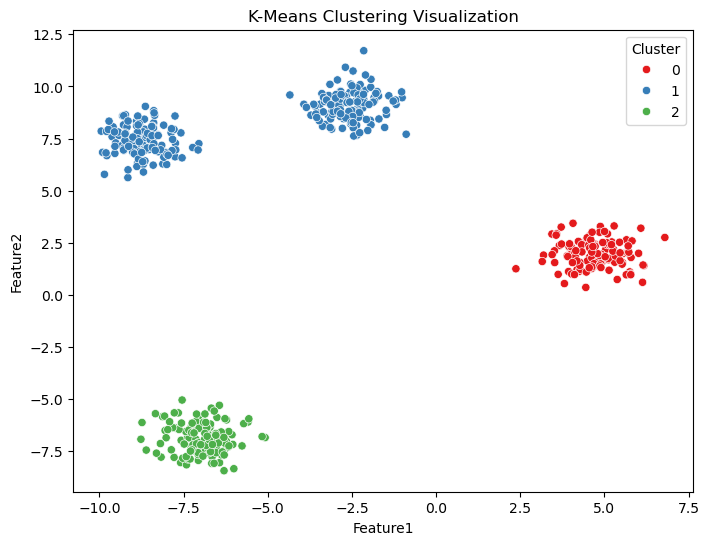

In [5]:
'''
Q4. Visualizing Clusters
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot of Clusters
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clustering Visualization")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")
plt.show()

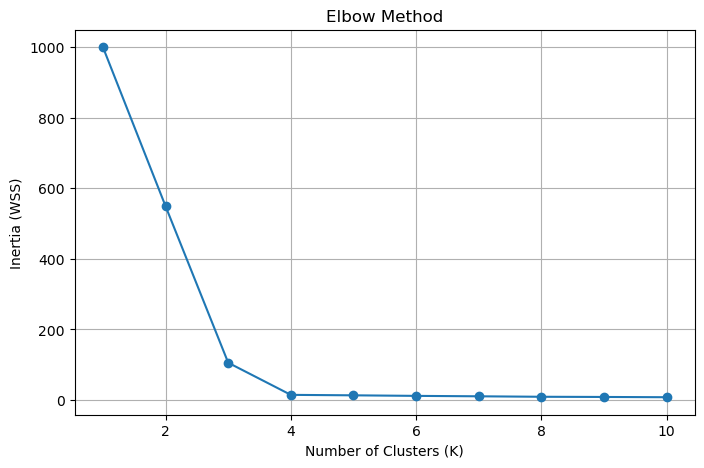

Optimal K Value: 4


In [6]:
'''
Q5. Elbow Method – Finding Optimal K
'''

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate Inertia for K = 1 to 10
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.grid(True)
plt.show()

print("Optimal K Value: 4")

In [7]:
'''
Q6. Final K-Means Model
'''

from sklearn.cluster import KMeans

# Train Final K-Means Model
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Fit Model and Predict Cluster Labels
df["Final_Cluster"] = final_kmeans.fit_predict(X_scaled)

# Display Number of Data Points in Each Cluster
print(df["Final_Cluster"].value_counts().sort_index())

Final_Cluster
0    125
1    125
2    125
3    125
Name: count, dtype: int64


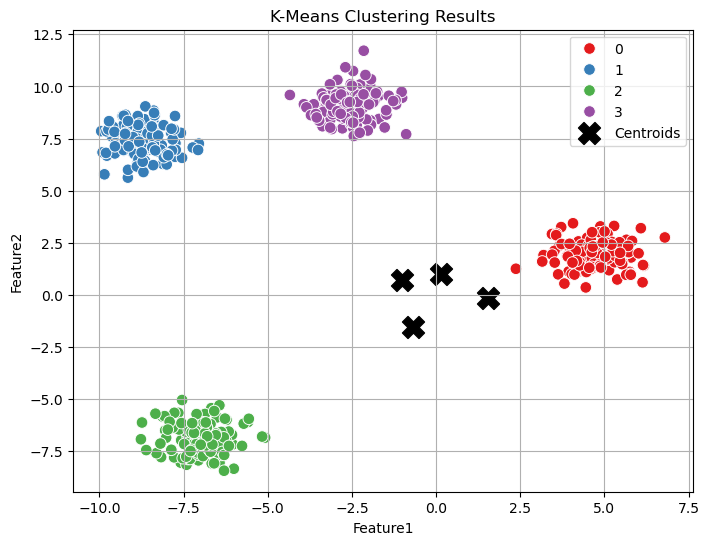

In [8]:
'''
Q7. Visualizing Final Clusters
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot of Final Clusters
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Final_Cluster",
    palette="Set1",
    s=70
)

# Plot Cluster Centroids
centroids = final_kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
'''
Q8. Real Dataset Application
'''

from sklearn.datasets import load_iris

# Load Iris Dataset
iris = load_iris()

# Create DataFrame
df_iris = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Select Numerical Features
X = df_iris

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df_iris["Cluster"] = kmeans.fit_predict(X_scaled)

# Display Cluster Counts
print(df_iris["Cluster"].value_counts())

# Display First 10 Rows
print(df_iris.head(10))

Cluster
0    96
1    33
2    21
Name: count, dtype: int64
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4      

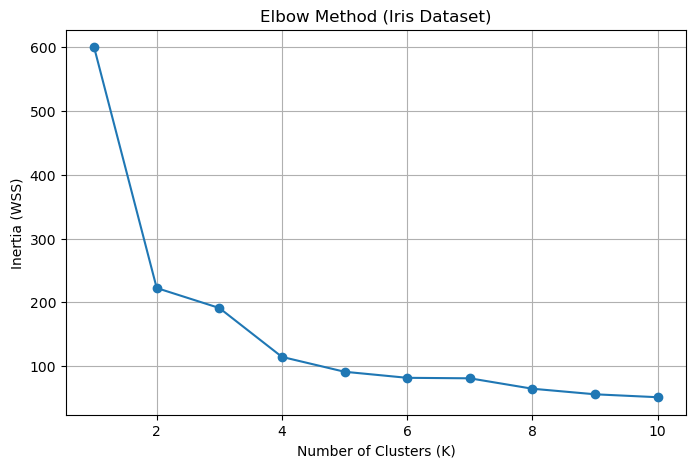

Final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [10]:
'''
Q9. Elbow Method on Real Dataset
'''

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker="o")

plt.title("Elbow Method (Iris Dataset)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSS)")
plt.grid(True)

plt.show()

# Final K-Means Model
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df_iris["Final_Cluster"] = final_kmeans.fit_predict(X_scaled)

# Print Cluster Sizes
print(df_iris["Final_Cluster"].value_counts().sort_index())